# 03 – Backtest: Regime-Based Allocation for a Euro Investor

**Question:** if an investor had followed the regime model in real time, with publication lags and trading costs, would they have done better than a static portfolio?

**Inputs:** `data/returns_eur.csv`, `data/returns_usd.csv`, `data/regimes.csv`
**Period:** 2006 – September 2026 (monthly)

## 1. Design

**Investor:** euro-based, using euro returns and Euro area regimes.

**Avoiding look-ahead bias:**
- **Publication lags.** Data for a given month is only fully published weeks later (Euro area industrial production about six weeks after month-end). The July regime is therefore only known in mid-September and can first be used for October returns. Regimes are shifted by **3 months** for the Euro area and 2 months for the US.
- **Tilts set in advance.** The regime tilts are based on economic reasoning, not on the results of `02_asset_returns`. Choosing tilts from the same data used to test them would make the backtest look better than it could have been in reality.

**Trading costs:** 0.1% of every euro traded. Portfolios are rebalanced monthly.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns_eur = pd.read_csv("../data/returns_eur.csv", index_col=0, parse_dates=True)
returns_usd = pd.read_csv("../data/returns_usd.csv", index_col=0, parse_dates=True)
regimes = pd.read_csv("../data/regimes.csv", index_col=0, parse_dates=True)

LAG_EA = 3
LAG_US = 2

signal_ea = regimes["ea_regime"].shift(LAG_EA, freq="MS")
signal_us = regimes["us_regime"].shift(LAG_US, freq="MS")

pd.DataFrame({"ea_regime": regimes["ea_regime"], "signal_ea": signal_ea}).loc["2020-01":"2020-08"]

,ea_regime,signal_ea
2020-01-01,Stagflation,Goldilocks
2020-02-01,Stagflation,Goldilocks
2020-03-01,Slowdown,Stagflation
2020-04-01,Slowdown,Stagflation
2020-05-01,Slowdown,Stagflation
2020-06-01,Slowdown,Slowdown
2020-07-01,Goldilocks,Slowdown
2020-08-01,Goldilocks,Slowdown


## 2. Portfolio weights

The strategy starts from a neutral portfolio and tilts it according to the regime.

| Asset | Neutral | Goldilocks | Overheating | Slowdown | Stagflation |
|---|---|---|---|---|---|
| SPY (US equities) | 25 | +10 | +5 | −5 | −10 |
| VGK (European equities) | 20 | +10 | +5 | −10 | −10 |
| TLT (long Treasuries) | 20 | | −10 | +10 | −5 |
| LQD (IG credit) | 10 | | −10 | | |
| SHY (short Treasuries) | 10 | −10 | | +5 | +10 |
| GLD (gold) | 10 | −10 | | +5 | +10 |
| DBC (commodities) | 5 | | +10 | −5 | +5 |

**Reasoning:**
- **Goldilocks:** profits grow and rates stay low → more equities, less protection (cash, gold).
- **Overheating:** strong demand and rising prices → more commodities; central banks raise rates → fewer long bonds and less credit.
- **Slowdown:** central banks cut rates → more long bonds and gold; the dollar tends to rise → more short US Treasuries (dollar cash for a euro investor); fewer equities and commodities.
- **Stagflation:** profits fall and rates rise → fewer equities and long bonds; more cash, gold and commodities.

Tilts sum to zero in each regime (always 100% invested) and no weight goes below zero (no short positions). Both conditions are checked with `assert`.

In [10]:
neutral = pd.Series({"SPY": 25, "VGK": 20, "TLT": 20, "LQD": 10, "SHY": 10, "GLD": 10, "DBC": 5})

tilts = pd.DataFrame({
    "Goldilocks":  {"SPY": 10, "VGK": 10, "SHY": -10, "GLD": -10},
    "Overheating": {"SPY": 5, "VGK": 5, "TLT": -10, "LQD": -10, "DBC": 10},
    "Slowdown":    {"SPY": -5, "VGK": -10, "TLT": 10, "SHY": 5, "GLD": 5, "DBC": -5},
    "Stagflation": {"SPY": -10, "VGK": -10, "TLT": -5, "SHY": 10, "GLD": 10, "DBC": 5},
}).fillna(0)

assert np.allclose(regime_weights.sum(), 1), "Weights don't sum to 1"
assert (regime_weights >= 0).all().all(), "Negative weight found"
regime_weights = tilts.add(neutral, axis=0) / 100
regime_weights


,Goldilocks,Overheating,Slowdown,Stagflation
DBC,0.05,0.15,0.00,0.10
GLD,0.00,0.10,0.15,0.20
LQD,0.10,0.00,0.10,0.10
SHY,0.00,0.10,0.15,0.20
SPY,0.35,0.30,0.20,0.15
TLT,0.20,0.10,0.30,0.15
VGK,0.30,0.25,0.10,0.10


## 3. Backtest method

Each month:
1. The lagged regime signal selects that month's weights.
2. The portfolio return is the weighted sum of the asset returns.
3. **Turnover** is the total change in weights since the previous month (moving 10% from equities to bonds = 20% turnover).
4. Trading costs (turnover × 0.1%) are subtracted.

**Benchmarks:**
- **Neutral:** the neutral weights, never changed. This is the fair comparison, since the strategy starts from the same portfolio.
- **60/40:** 30% US equities, 30% European equities, 40% long Treasuries.

**Simplification:** benchmarks are assumed to stay exactly at their weights with no trading costs. In reality they would drift and need small rebalancing trades. This slightly flatters the benchmarks, making the test harder for the strategy, not easier.

In [11]:
COST = 0.001

def backtest(returns, signal, regime_weights, cost=COST):
    signal = signal.dropna()
    dates = returns.index.intersection(signal.index)

    weights = regime_weights.T.loc[signal.loc[dates]].set_axis(dates)
    weights = weights[returns.columns]

    gross = (weights * returns.loc[dates]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    net = gross - turnover * cost

    return net, weights, turnover

strategy, weights_ea, turnover_ea = backtest(returns_eur, signal_ea, regime_weights)

In [12]:
def static_portfolio(returns, w):
    return (returns[w.index] * w).sum(axis=1)

w_6040 = pd.Series({"SPY": 0.30, "VGK": 0.30, "TLT": 0.40})
w_neutral = neutral / 100

results = pd.DataFrame({
    "Regime strategy": strategy,
    "Neutral": static_portfolio(returns_eur, w_neutral),
    "60/40": static_portfolio(returns_eur, w_6040),
}).dropna()

growth = 100 * (1 + results).cumprod()
growth.tail(1).round(1)

,Regime strategy,Neutral,60/40
2026-09-01,424.9,399.1,397.9


In [13]:
def performance(r):
    years = len(r) / 12
    wealth = (1 + r).cumprod()

    annual_return = wealth.iloc[-1] ** (1 / years) - 1
    volatility = r.std() * np.sqrt(12)
    drawdown = wealth / wealth.cummax() - 1

    return pd.Series({
        "Annual return (%)": annual_return * 100,
        "Volatility (%)": volatility * 100,
        "Return / volatility": annual_return / volatility,
        "Max drawdown (%)": drawdown.min() * 100,
    })

stats = results.apply(performance)
stats.round(2)

,Regime strategy,Neutral,60/40
Annual return (%),7.31,6.98,6.97
Volatility (%),8.31,8.04,9.76
Return / volatility,0.88,0.87,0.71
Max drawdown (%),-15.58,-16.25,-24.50


## 4. Results (Euro area regimes, 3-month lag, after costs)

| | Regime strategy | Neutral | 60/40 |
|---|---|---|---|
| Value of €100 | 424.9 | 399.1 | 397.9 |
| Annual return | 7.31% | 6.98% | 6.97% |
| Volatility | 8.31% | 8.04% | 9.76% |
| Return / volatility | 0.88 | 0.87 | 0.71 |
| Max drawdown | −15.6% | −16.3% | −24.5% |

*Return / volatility is a simplified Sharpe ratio, without subtracting the risk-free rate.*

**Interpretation:**
- The strategy earned about 0.3 points a year more than the neutral portfolio, with slightly higher volatility. **Adjusted for risk, regime timing added almost nothing.**
- **The neutral portfolio clearly beat 60/40 on risk**: similar return, lower volatility, and a much smaller worst loss (−16% vs −24.5%). **The main benefit came from diversification** (gold, commodities, credit and cash alongside equities and bonds), not from timing.

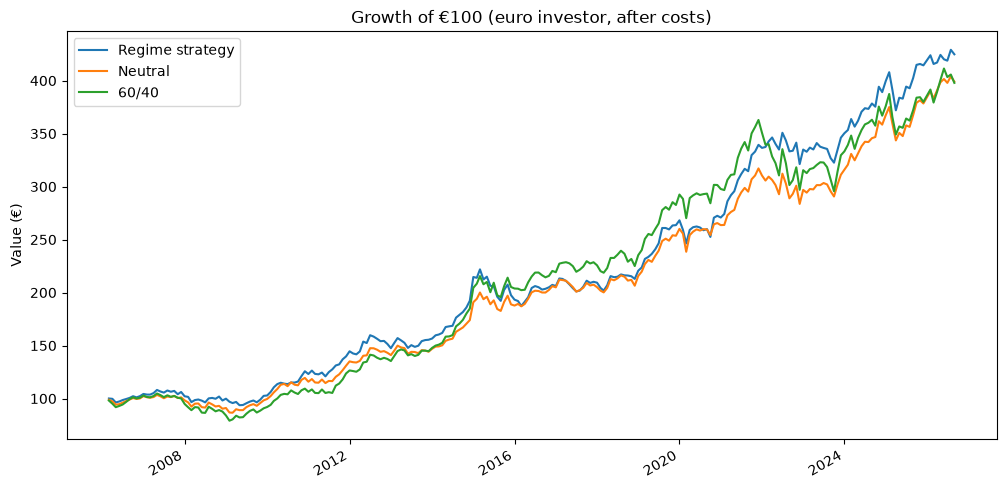

In [14]:
growth.plot(figsize=(12, 6), title="Growth of €100 (euro investor, after costs)")
plt.ylabel("Value (€)")
plt.show()

In [15]:
print(f"Average turnover per year: {turnover_ea.mean() * 12 * 100:.0f}% of the portfolio")
print(f"Total trading costs over the period: {turnover_ea.sum() * COST * 100:.1f}%")

Average turnover per year: 195% of the portfolio
Total trading costs over the period: 4.0%


### Trading activity

- **Turnover:** about **195% of the portfolio per year**. Each variable switches every 6–8 months, but the regime changes whenever either variable switches, so the portfolio is repositioned every few months.
- **Costs:** about **4% in total**, or 0.2% a year. Before costs, the edge was about 0.5% a year, so **costs absorbed roughly 40% of it**. At a more conservative 0.2% per trade, most of the remaining advantage would disappear.

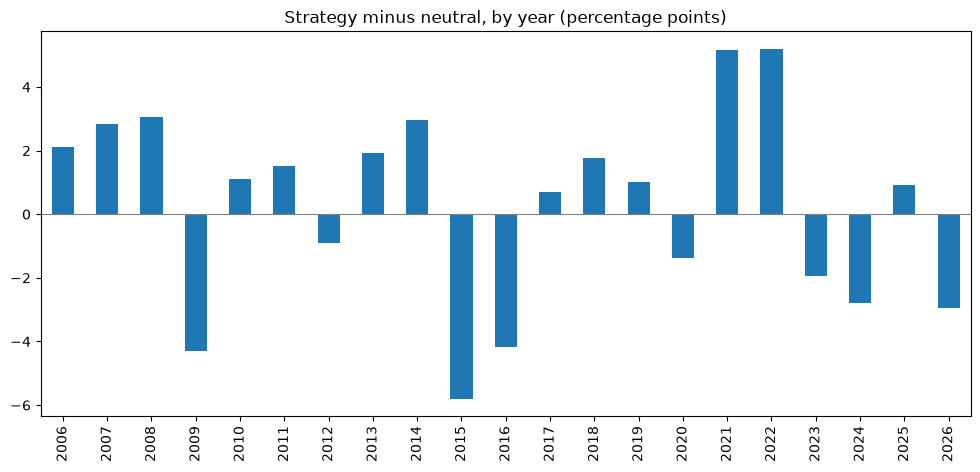

2006    2.1
2007    2.8
2008    3.1
2009   -4.3
2010    1.1
2011    1.5
2012   -0.9
2013    1.9
2014    3.0
2015   -5.8
2016   -4.2
2017    0.7
2018    1.8
2019    1.0
2020   -1.4
2021    5.2
2022    5.2
2023   -1.9
2024   -2.8
2025    0.9
2026   -2.9
dtype: float64

In [16]:
yearly = (1 + results).groupby(results.index.year).prod() - 1
excess = (yearly["Regime strategy"] - yearly["Neutral"]) * 100

excess.plot(kind="bar", figsize=(12, 5), title="Strategy minus neutral, by year (percentage points)")
plt.axhline(0, color="grey", linewidth=0.8)
plt.show()

excess.round(1)

### Year-by-year

The strategy beat the neutral portfolio in **13 of 21 years**, but the gains were concentrated in two or three years, and it underperformed for most of 2016–2022. A real investor would have found such a long period of underperformance hard to tolerate.

**Example of the lag problem (2020):** the Euro area entered Slowdown in March 2020, but with a 3-month lag the signal only switched in June. The strategy spent March–May positioned for the previous regime, then reduced equities from June, just as markets were recovering.

In [18]:
nets = {}
turns = {}

for lag in range(0, 5):
    sig = regimes["ea_regime"].shift(lag, freq="MS")
    net, _, turn = backtest(returns_eur, sig, regime_weights)
    nets[f"Lag {lag}"] = net
    turns[f"Lag {lag}"] = turn

all_nets = pd.DataFrame(nets).dropna()
all_nets["Neutral"] = results["Neutral"]
all_nets = all_nets.dropna()

lag_table = all_nets.apply(performance)
lag_table.loc["Turnover per year (%)"] = pd.Series(
    {name: t.mean() * 12 * 100 for name, t in turns.items()}
)
lag_table.round(2)

,Lag 0,Lag 1,Lag 2,Lag 3,Lag 4,Neutral
Annual return (%),9.17,8.09,7.82,7.14,7.42,6.83
Volatility (%),8.27,8.24,8.17,8.37,8.54,8.08
Return / volatility,1.11,0.98,0.96,0.85,0.87,0.85
Max drawdown (%),-11.09,-10.83,-10.54,-15.58,-12.74,-16.25
Turnover per year (%),193.28,195.43,194.63,194.63,194.63,NaN


## 5. How much does the publication lag cost?

The backtest was repeated with lags of 0 to 4 months, over the same period for all versions. Lag 0 is unrealistic: it assumes each month's regime is known instantly. It shows the maximum value of the regime idea.

| | Lag 0 | Lag 1 | Lag 2 | **Lag 3** | Lag 4 | Neutral |
|---|---|---|---|---|---|---|
| Annual return | 9.17% | 8.09% | 7.82% | **7.14%** | 7.42% | 6.83% |
| Return / volatility | 1.11 | 0.98 | 0.96 | **0.85** | 0.87 | 0.85 |
| Max drawdown | −11.1% | −10.8% | −10.5% | **−15.6%** | −12.7% | −16.3% |

*Slightly shorter period than Section 4, because Lag 0 has no signal for the latest months. This is why the neutral return differs.*

**Key finding:** with perfect information, regime tilts would have added **2.3 percentage points a year**. With the realistic 3-month lag, the advantage falls to **0.3 points**, and risk-adjusted performance matches the static portfolio. **About 87% of the potential edge is lost to the publication lag.** The regimes are informative, but the data arrives too late.

Lag 4 performing slightly better than Lag 3 does not mean waiting helps. It shows that differences between versions are noisy and can depend on a few specific months.

## 6. Data issue: October 2025

October 2025 US CPI was never published because of the US federal government shutdown. In the current version, the combined data table drops any month with a missing value, so October 2025 was removed for **both** regions, even though the Euro area data was complete. It will also affect US year-on-year inflation for October 2026.

**Planned fix:** build regimes separately for each region, and interpolate the single missing US CPI value.

## 7. Conclusions

1. **The regime framework contains real information:** with instant knowledge of the regime, tilts would have improved return, risk-adjusted return and drawdowns.
2. **Publication lags destroy most of that value:** with realistic lags, the strategy only matches the neutral portfolio on a risk-adjusted basis.
3. **Diversification did the heavy lifting:** the static neutral portfolio was far smoother than 60/40.
4. **Trading costs matter:** the strategy turns over its portfolio nearly twice a year, and costs absorbed about 40% of the gross edge.

## 8. Next steps

- Use **faster Euro area data**: Eurostat's flash HICP estimate and the European Commission's Economic Sentiment Indicator, both published at the end of the same month. This would cut the lag to about 1 month (worth about +1 point a year in the lag test) and replace the noisy industrial production signal.
- Fix the October 2025 gap and build regimes by region.
- Robustness: higher trading costs, the US / dollar version, and reducing turnover (e.g. only switching when the change is clearly significant).